# **Time-Series Analytics and Forecasting project**

In [2]:
import os
import numpy as np
import pandas as pd

import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

## **Load & Clean Data**

In [3]:
for split_dataset in ['train', 'test', 'validation']:
    path = f'../data/{split_dataset}'
    print(f"Dataset: {split_dataset}")
    for i in os.listdir(path):
        df = pd.read_csv(f'{path}/{i}', parse_dates=['Date'])
        print(f"{split_dataset}/{i}: {len(df)} rows, "
              f"NaN={df.isnull().sum().sum()}, "
              f"Date range: {df['Date'].min()} -> {df['Date'].max()}")

Dataset: train
train/1.csv: 495 rows, NaN=0, Date range: 2024-05-13 00:00:00 -> 2026-05-13 00:00:00
train/10.csv: 494 rows, NaN=0, Date range: 2024-05-13 00:00:00 -> 2026-05-13 00:00:00
train/12.csv: 495 rows, NaN=0, Date range: 2024-05-13 00:00:00 -> 2026-05-13 00:00:00
train/14.csv: 495 rows, NaN=0, Date range: 2024-05-13 00:00:00 -> 2026-05-13 00:00:00
train/16.csv: 495 rows, NaN=0, Date range: 2024-05-13 00:00:00 -> 2026-05-13 00:00:00
train/17.csv: 478 rows, NaN=0, Date range: 2024-05-13 00:00:00 -> 2026-05-13 00:00:00
train/18.csv: 495 rows, NaN=0, Date range: 2024-05-13 00:00:00 -> 2026-05-13 00:00:00
train/2.csv: 402 rows, NaN=0, Date range: 2024-09-23 00:00:00 -> 2026-05-13 00:00:00
train/20.csv: 495 rows, NaN=0, Date range: 2024-05-13 00:00:00 -> 2026-05-13 00:00:00
train/21.csv: 189 rows, NaN=0, Date range: 2025-08-04 00:00:00 -> 2026-05-13 00:00:00
train/24.csv: 494 rows, NaN=0, Date range: 2024-05-13 00:00:00 -> 2026-05-13 00:00:00
train/25.csv: 495 rows, NaN=0, Date range

### **Insights**
#### **- Dataset contains 25 individual stocks from the Athens Stock Exchange**
#### **- Split is stock-based (not time-based): 17 train / 3 validation / 5 test stocks**
#### **- Date Range is 2 years from 2024-05-13 to 2026-05-13 (trading days only, Mon-Fri)**
#### **- ~495 trading days per stock (excluding weekends and ASE holidays)**
#### **- No missing values (NaN=0) across all stocks and all splits (train/test/validation)**
#### **- 3 stocks have shorter histories (2.csv, 6.csv, 21.csv) as they are newly listed**


### **We should probably build concatenated df for each split. We should union all stocks of each split together**

#### Load all stock dataframes in a single dictionary (key=split and df is the stock)

In [4]:
all_dataframes = {}

for split_dataset in ['train', 'test', 'validation']:
    path = f'../data/{split_dataset}'
    all_dataframes[split_dataset] = {}  # nested dictionary per split {split: {stock_id: dataframe}}

    for i in sorted(os.listdir(path)):
        if i.endswith('.csv'):
            stock_id = i.replace('.csv', '')  #  we split dataframes by stock_id '1.csv' as'1'
            df = pd.read_csv(f'{path}/{i}', parse_dates=['Date'])
            df = df.sort_values('Date').reset_index(drop=True)
            all_dataframes[split_dataset][f'stock_{stock_id}'] = df

# Verify
for split, stocks in all_dataframes.items():
    print(f"{split}: {list(stocks.keys())}")

train: ['stock_1', 'stock_10', 'stock_12', 'stock_14', 'stock_16', 'stock_17', 'stock_18', 'stock_2', 'stock_20', 'stock_21', 'stock_24', 'stock_25', 'stock_3', 'stock_4', 'stock_5', 'stock_6', 'stock_7']
test: ['stock_11', 'stock_13', 'stock_15', 'stock_22', 'stock_8']
validation: ['stock_19', 'stock_23', 'stock_9']


In [5]:
all_dataframes.keys()

dict_keys(['train', 'test', 'validation'])

In [6]:
all_dataframes.values()

dict_values([{'stock_1':           Date  Close   High    Low   Open  Volume
0   2024-05-13   5.43   5.50   5.37   5.49  233043
1   2024-05-14   5.33   5.41   5.33   5.40   37146
2   2024-05-15   5.35   5.36   5.25   5.30  336069
3   2024-05-16   5.29   5.39   5.18   5.39  204403
4   2024-05-17   5.26   5.34   5.20   5.25  162397
..         ...    ...    ...    ...    ...     ...
490 2026-05-07  11.30  11.50  11.14  11.44  192095
491 2026-05-08  11.26  11.32  11.10  11.30  236903
492 2026-05-11  11.20  11.36  11.08  11.16  140573
493 2026-05-12  10.90  11.30  10.86  11.06  204700
494 2026-05-13  10.80  10.98  10.70  10.98   25991

[495 rows x 6 columns], 'stock_10':           Date   Close    High     Low    Open   Volume
0   2024-05-13   8.350   8.406   8.330   8.400   147801
1   2024-05-14   8.310   8.390   8.310   8.350   128421
2   2024-05-15   8.332   8.450   8.332   8.400   322010
3   2024-05-16   8.350   8.410   8.350   8.386   308399
4   2024-05-17   8.356   8.400   8.332   8.400

#### Check first 10 rows of stock 1 dataframe in train split

In [7]:
all_dataframes['train']['stock_1'].head(10)

,Date,Close,High,Low,Open,Volume
0,2024-05-13,5.43,5.50,5.37,5.49,233043
1,2024-05-14,5.33,5.41,5.33,5.40,37146
2,2024-05-15,5.35,5.36,5.25,5.30,336069
3,2024-05-16,5.29,5.39,5.18,5.39,204403
4,2024-05-17,5.26,5.34,5.20,5.25,162397
5,2024-05-20,5.25,5.31,5.17,5.27,126157
6,2024-05-21,5.22,5.25,5.12,5.19,162801
7,2024-05-22,5.20,5.30,5.12,5.30,426850
8,2024-05-23,5.21,5.21,5.16,5.21,41040
9,2024-05-24,5.18,5.20,5.10,5.15,141634


#### Check all Date column's value for stock 1, to figure if only trading days are recording

In [8]:
all_dataframes['train']['stock_1'].columns


Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [9]:
df = all_dataframes['train']['stock_1'].copy()
df['DayOfWeek'] = df['Date'].dt.day_name()
df[df['Date'] > '2024-12-21'][['Date', 'DayOfWeek']].head(20)
# we choose Christmas period for the analysis to see if there are any events in the data during off days like Christmas and New Year's Day.

,Date,DayOfWeek
157,2024-12-23,Monday
158,2024-12-27,Friday
159,2024-12-30,Monday
160,2024-12-31,Tuesday
161,2025-01-02,Thursday
162,2025-01-03,Friday
163,2025-01-07,Tuesday
164,2025-01-08,Wednesday
165,2025-01-09,Thursday
166,2025-01-10,Friday


#### **Data are only available for trading days (Monday to Friday), excluding weekends and ASE public holidays**

#### Keep only full 5-day weeks for all stocks

In [10]:
def filter_complete_weeks(df):
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)

    df['iso_year'] = df['Date'].dt.isocalendar().year
    # According to ISO standard 8601 and ISO standard 2015, Thursday is the middle day of a week.
    # Therefore, ISO years always start with Monday
    df['iso_week'] = df['Date'].dt.isocalendar().week

    week_counts = df.groupby(['iso_year', 'iso_week']).size()
    complete_weeks = week_counts[week_counts == 5].index

    mask = df.set_index(['iso_year', 'iso_week']).index.isin(complete_weeks)
    df_filtered = df[mask].drop(columns=['iso_year', 'iso_week']).reset_index(drop=True)

    return df_filtered


# Apply to all stocks in all splits
all_dataframes_filtered = {}

for split, stocks in all_dataframes.items():
    all_dataframes_filtered[split] = {}
    for stock_name, df in stocks.items():
        df_filtered = filter_complete_weeks(df)
        all_dataframes_filtered[split][stock_name] = df_filtered
        
        removed = len(df) - len(df_filtered)
        if removed > 0:
            print(f"{split}/{stock_name}: removed {removed} rows ({len(df)} -> {len(df_filtered)})")

print("\nFiltered dataframes:")
for split, stocks in all_dataframes_filtered.items():
    for stock_name, df_filtered in stocks.items():
        print(f"{split}/{stock_name}: {len(df_filtered)} rows")

# Christmas test for filtered data on stock 1
df_filtered_s1 = all_dataframes_filtered['train']['stock_1']
df_filtered_s1['DayOfWeek'] = df_filtered_s1['Date'].dt.day_name()
df_filtered_s1[df_filtered_s1['Date'] > '2024-12-21'][['Date', 'DayOfWeek']].head(20)

train/stock_1: removed 90 rows (495 -> 405)
train/stock_10: removed 94 rows (494 -> 400)
train/stock_12: removed 90 rows (495 -> 405)
train/stock_14: removed 90 rows (495 -> 405)
train/stock_16: removed 90 rows (495 -> 405)
train/stock_17: removed 83 rows (478 -> 395)
train/stock_18: removed 90 rows (495 -> 405)
train/stock_2: removed 82 rows (402 -> 320)
train/stock_20: removed 90 rows (495 -> 405)
train/stock_21: removed 44 rows (189 -> 145)
train/stock_24: removed 89 rows (494 -> 405)
train/stock_25: removed 90 rows (495 -> 405)
train/stock_3: removed 90 rows (495 -> 405)
train/stock_4: removed 90 rows (495 -> 405)
train/stock_5: removed 90 rows (495 -> 405)
train/stock_6: removed 47 rows (212 -> 165)
train/stock_7: removed 90 rows (495 -> 405)
test/stock_11: removed 90 rows (495 -> 405)
test/stock_13: removed 90 rows (495 -> 405)
test/stock_15: removed 90 rows (495 -> 405)
test/stock_22: removed 90 rows (495 -> 405)
test/stock_8: removed 90 rows (495 -> 405)
validation/stock_19: re

,Date,DayOfWeek
145,2025-01-13,Monday
146,2025-01-14,Tuesday
147,2025-01-15,Wednesday
148,2025-01-16,Thursday
149,2025-01-17,Friday
150,2025-01-20,Monday
151,2025-01-21,Tuesday
152,2025-01-22,Wednesday
153,2025-01-23,Thursday
154,2025-01-24,Friday


#### We can clearly see that the filtered dataset does not contain any rows for the Christmas period, which is expected since those days are not trading days. This filtering ensures that our analysis focuses only on complete trading weeks.

**Notes for the report**
What other methods were available? e.g. Interpolate.
Pros-cons? Why did we choose to drop weeks that include Bank holidays?


In [11]:
for split in all_dataframes_filtered:
    sum=0
    for stock_name, df_filtered in all_dataframes_filtered[split].items():  # We take each stock dataframe in the split
        # we sum up the number of rows in each dataframe to get the total number of rows per split
        sum += df_filtered.shape[0]
    print(f"{split} total: {sum} rows")

train total: 6285 rows
test total: 2025 rows
validation total: 1215 rows


#### Create 5-days training windows in each stock dataframe

In [41]:
def create_windows(df, stock_id=None, input_size=5, output_size=5):
    """
    Input:  Open, High, Low, Close, and Volume data for 5 consecutive trading days (current week) -> shape (5, 5) 5 days of input data
    Target: Close prices for next 5 consecutive trading days (next week) -> shape (5,) 5 days of Close prices
    """
    X, y, ids = [], [], []
    
    input_data = df[['Open', 'High', 'Low', 'Close', 'Volume']].values
    close = df['Close'].values # Target variable is the Close price for the next 5 days
    
    for i in range(len(df) - input_size - output_size + 1):
        X.append(input_data[i : i + input_size])                                   
        y.append(close[i + input_size : i + input_size + output_size])         
        ids.append(stock_id)

    return np.array(X), np.array(y), ids

# Create windows for all stocks in all splits
all_windows = {}

for split, stocks in all_dataframes_filtered.items():
    X_list, y_list = [], []
    for stock_name, df in stocks.items():
        X, y, _ = create_windows(df)
        X_list.append(X)
        y_list.append(y)
    
    all_windows[split] = {
        'X': np.concatenate(X_list, axis=0),
        'y': np.concatenate(y_list, axis=0)
    }

for split, data in all_windows.items():
    print(f"{split}: X={data['X'].shape}, y={data['y'].shape}")

train: X=(6132, 5, 5), y=(6132, 5)
test: X=(1980, 5, 5), y=(1980, 5)
validation: X=(1188, 5, 5), y=(1188, 5)


Decision 1: What features to use as input

Your create_windows function currently uses all 5 features: [Open, High, Low, Close, Volume]. Your own EDA already showed that Open, High, Low, and Close are almost perfectly correlated with each other (~0.99 average). This creates redundancy. You have two defensible options:


Option A — Keep all 5 features (current approach). Justified because the model might learn intraday range (High−Low) as a volatility signal. Easy to implement, nothing to change. Document the correlation finding in the report and note it as a known redundancy.


Option B — Close only. Simpler, cleaner, reduces the OHLCV carry-forward problem in autoregressive prediction. Many stock forecasting papers use only Close. Also makes inverse-scaling trivial since there's only one feature to invert.


**My recommendation: keep all 5 for now, but add a feature ablation note in the report. The professor asked about hyperparameters and design choices — this is one.**


## **Exploratory Data Analysis**

### **Stock Trends**

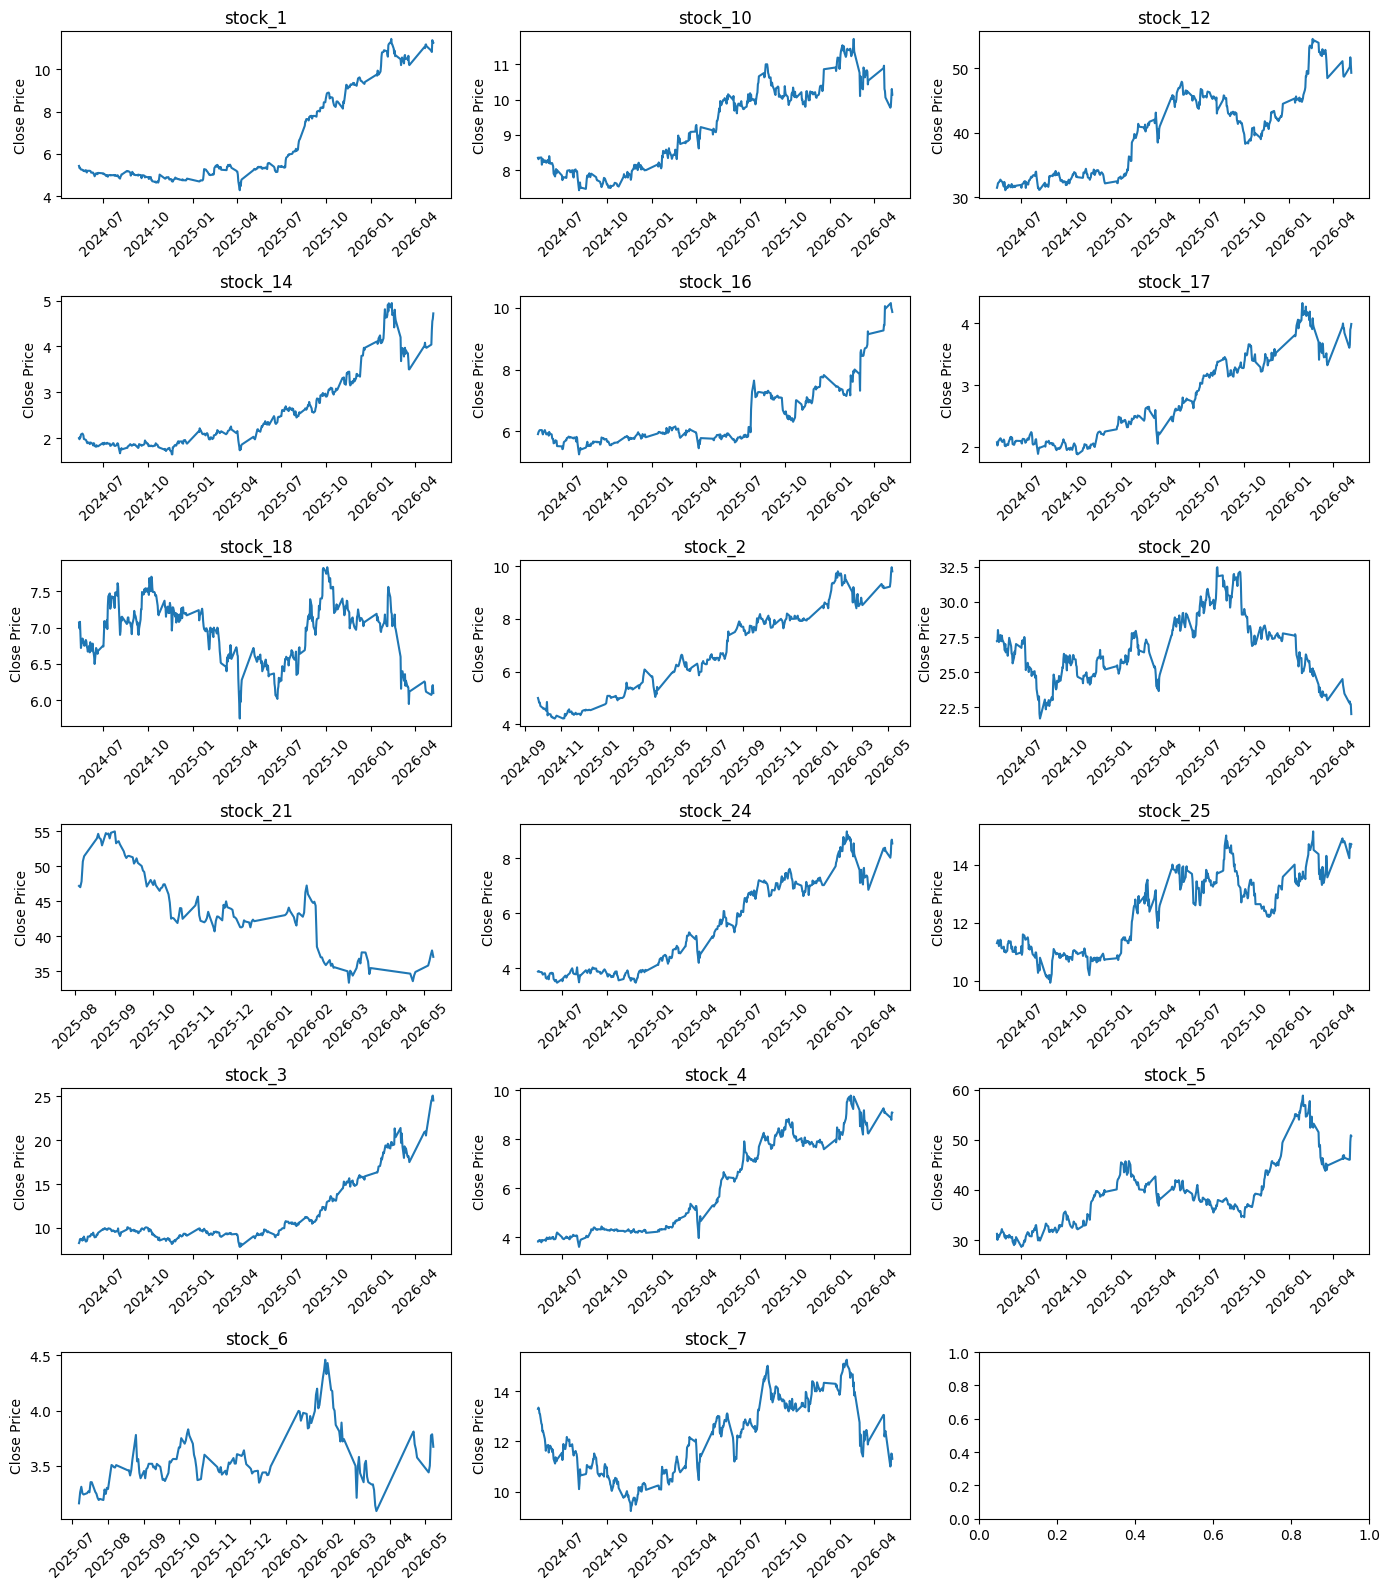

In [13]:
fig, axes = plt.subplots(6, 3, figsize=(14, 16))
for ax, (stock_name, df_filtered_train) in zip(axes.flat, all_dataframes_filtered['train'].items()):
    ax.plot(df_filtered_train['Date'], df_filtered_train['Close'])
    ax.set_title(stock_name)
    ax.set_ylabel('Close Price')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### **Key Insights:**
 - **Increase in closing prices** Most of the stocks tend to have increase in their closing price over time with few exceptions such as stock 6, stock 20 etc.

 - **Prices ranging** We also see difference in price range with stock 12 featuring closing prices up to 55 euros while stock 6 featuring prices on the lower end**

#### For this reason we will probably scale per stock later

The problem: when you fit_transform on a validation stock, the scaler learns that stock's min/max. The model then sees inputs in [0,1] space that were scaled using information the training process had no access to.
Since your split is stock-based (completely different stocks in each set), there's no single clean "fit on train, transform val/test" solution like you'd have with a time-based split. You have two options:
Option A — Fit scaler per stock on its own full history (current behavior), document it.

This is actually defensible for stock data because each stock has a completely different price range and the alternative (using train stock scalers on test stocks) makes even less sense. The key is to be explicit in the report: "Each stock is normalised independently using its own min-max range, since stocks operate on fundamentally different price scales. This is standard practice in multi-stock forecasting."

### **Correlation heatmap between stocks**

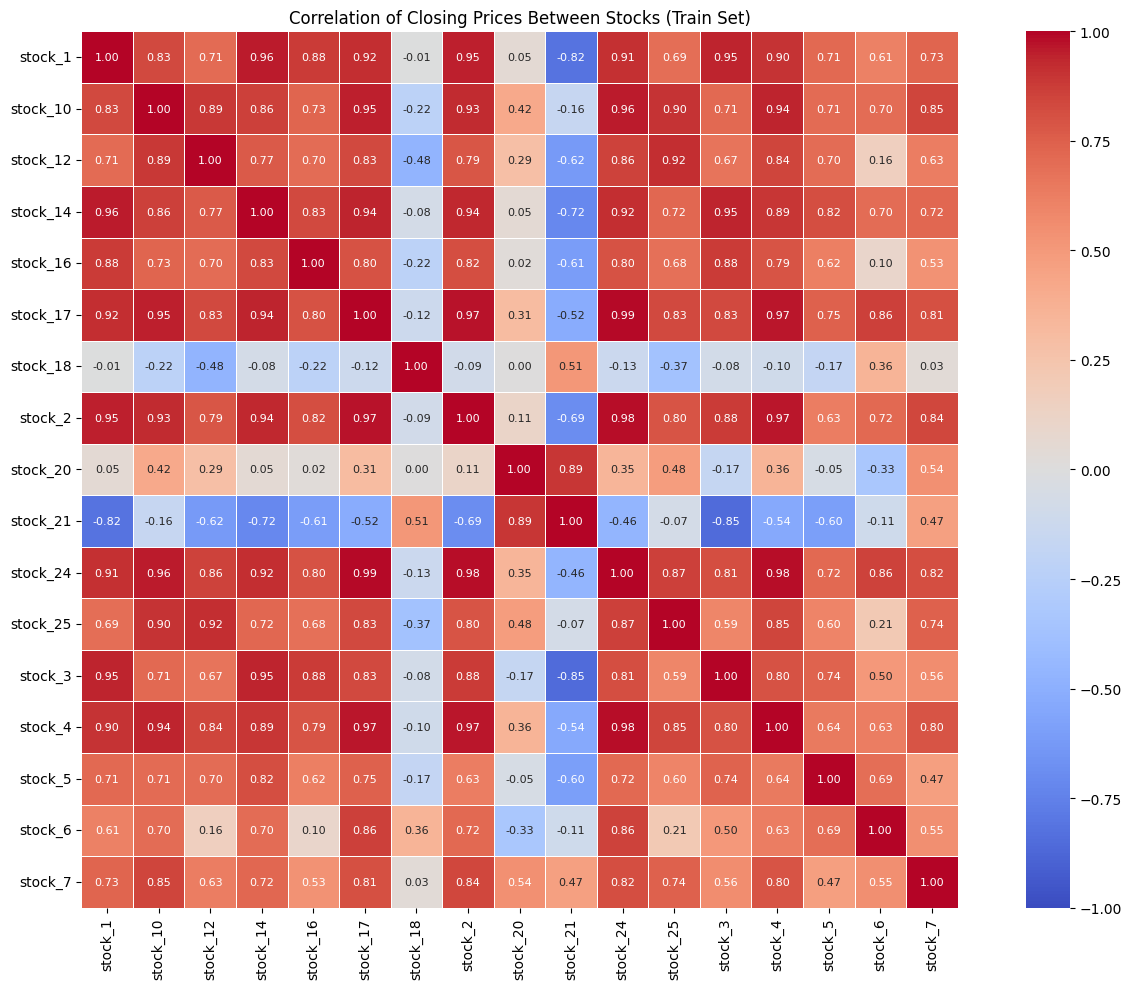

In [14]:
closed_prices = pd.DataFrame({name: df_filtered_train.set_index('Date')['Close'] 
                        for name, df_filtered_train in all_dataframes_filtered['train'].items()})
plt.figure(figsize=(14, 10))
sns.heatmap(closed_prices.corr(), annot=True, fmt='.2f', cmap='coolwarm', 
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Correlation of Closing Prices Between Stocks (Train Set)')
plt.tight_layout()
plt.show()

#### **Key insights**

- **High inter-stock correlation** Many stocks present high positive correlation among them (>70%) 
 
  
- **stock_21** presents negative correlation with most stocks, including strong negative correlation with stock 1 and 3. This makes sense cause from the trend analysis above we discovered that altough most trends and especially stocks 1 and 3 present an increase in closing prices, stock 21 presents a drop

- **stock_18** appears largely uncorrelated with the rest of the market 

- **stock_20 and stock_21** show the strongest pairwise correlation (0.89) among, both exhibiting similar sideways/declining patterns.



- Adding a note here that stock_21 has 145 rows

Decision 3: Handling the shorter-history stocks
Stocks 2, 6, and 21 have significantly fewer rows (~189–402 vs ~495). They're all in the training set, which is actually fine — the window creation handles variable-length series naturally, they just contribute fewer windows. What you should add is a note in the report acknowledging this and verifying the window counts are proportional.

### Average correlation across stocks for all numerical columns

In [42]:
sample_df = list(all_dataframes_filtered['train'].values())[0] # Take the first stock df
cols = sample_df.select_dtypes(include=[np.number]).columns.tolist() # Take the numeric columns from the dataframe
print(cols)

['Close', 'High', 'Low', 'Open', 'Volume']


Average correlation matrix across all stocks (train set):
           Close      High       Low      Open    Volume
Close   1.000000  0.996023  0.996019  0.990844  0.086514
High    0.996023  1.000000  0.995429  0.995807  0.100268
Low     0.996019  0.995429  1.000000  0.995769  0.074499
Open    0.990844  0.995807  0.995769  1.000000  0.087025
Volume  0.086514  0.100268  0.074499  0.087025  1.000000


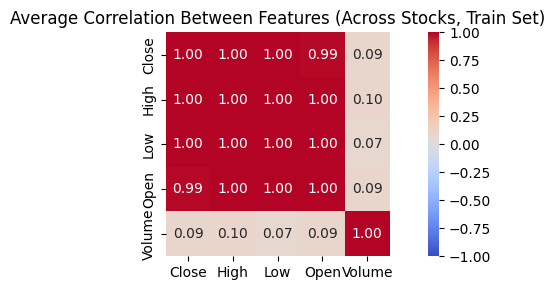

In [43]:
corr_matrices = []

for stock_name, df_filtered_train in all_dataframes_filtered['train'].items():
    # print(stock_name)
    # print(df.head())
    corr_matrices.append(df_filtered_train[cols].corr())# append the correlation matrix of each stock to the list
# From the list calculate the average correlation matrix by summing up all the correlation matrices and dividing by the number of stocks
avg_corr = np.sum(corr_matrices, axis=0) / len(corr_matrices)
avg_corr = pd.DataFrame(avg_corr, index=cols, columns=cols)

print("Average correlation matrix across all stocks (train set):")
print(avg_corr)

plt.figure(figsize=(8, 3))
sns.heatmap(avg_corr, annot=True, fmt='.2f', cmap='coolwarm', 
            vmin=-1, vmax=1, square=True)
plt.title('Average Correlation Between Features (Across Stocks, Train Set)')
plt.tight_layout()
plt.show()

### **Key Insights**

- **Almost perfect average correlation across (Close,Open,High,Low)** All these features might be redundant
- **Low correlation with Volume**

### Returns Analysis (Because raw stock prices vary this is a safer way to analyse them)

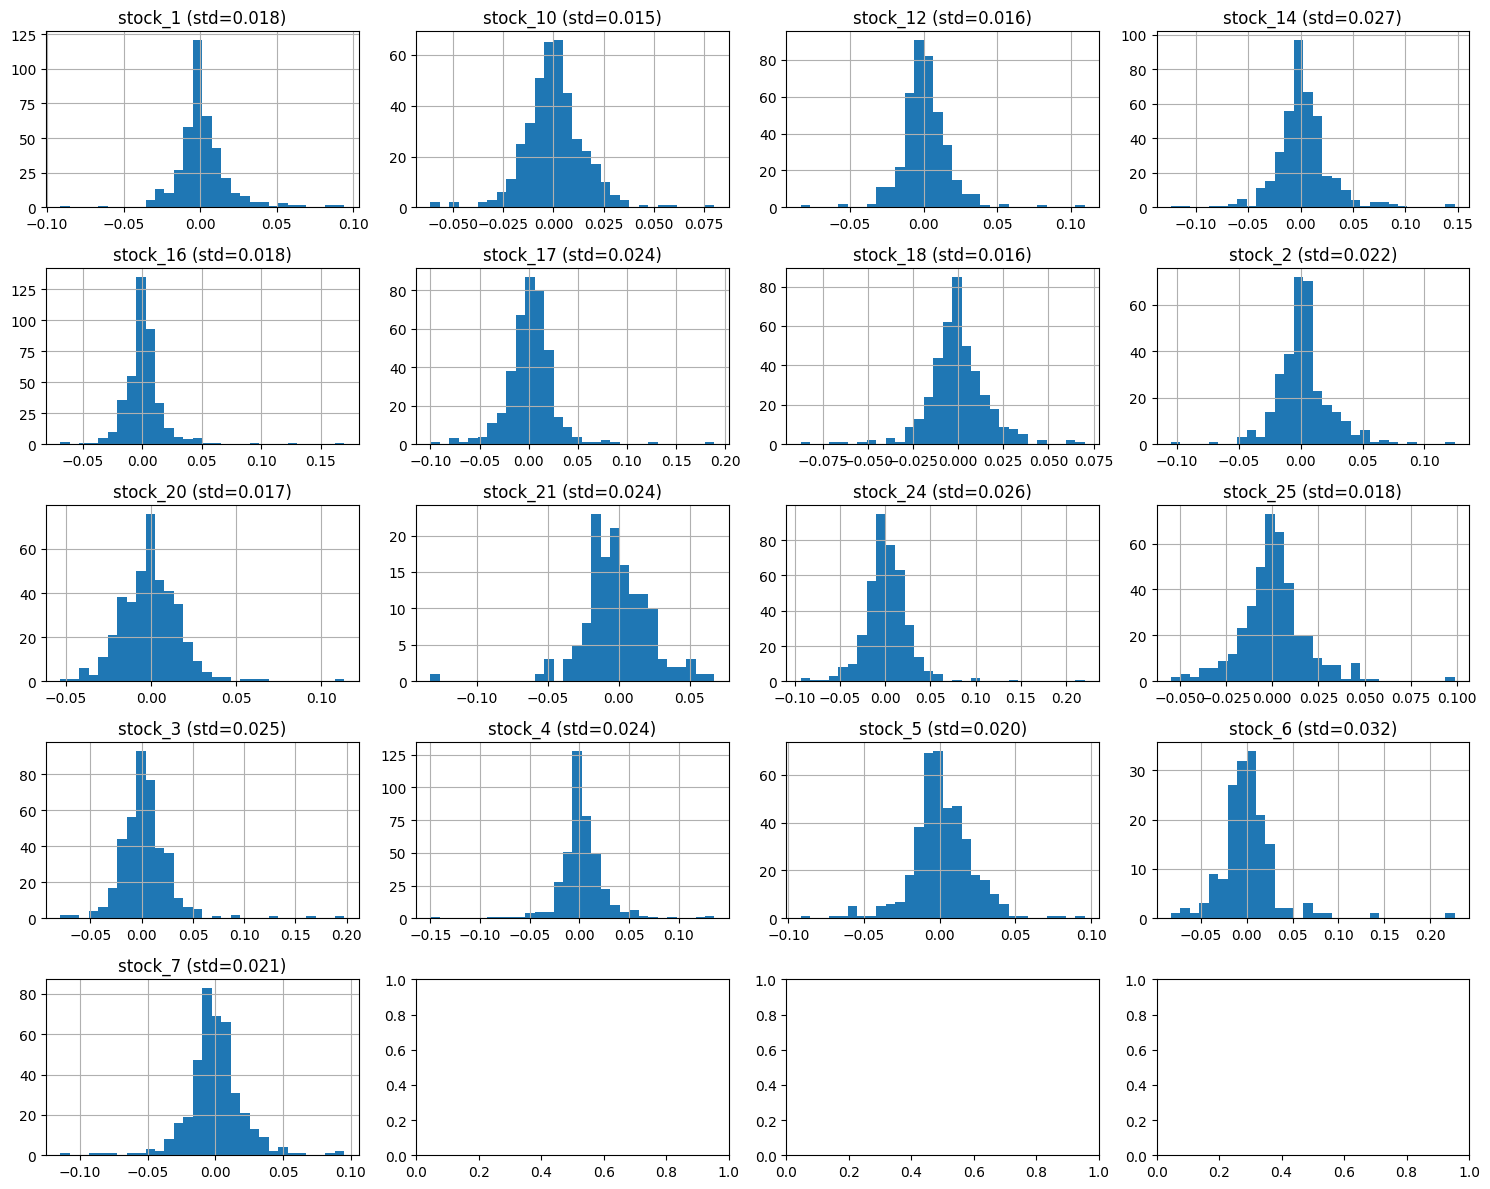

In [44]:
fig, axes = plt.subplots(5, 4, figsize=(15, 12))
for ax, (stock_name, df_filtered_train) in zip(axes.flat, all_dataframes_filtered['train'].items()):
    returns = df_filtered_train['Close'].pct_change().dropna()
    returns.hist(ax=ax, bins=30)
    plt.tight_layout()
    ax.set_title(f"{stock_name} (std={returns.std():.3f})")

## **Models**

### **Data Preprocessing**

As we mentioned earlier stock prices vary significantly across the dataset (e.g., stock_6 
ranges ~3-4.5€ while stock_12 ranges ~30-55€), and Volume operates on an entirely 
different scale (tens of thousands to over a million). Feature scaling is essential 
for stable neural network training.

We apply **MinMaxScaler independently per stock**, fitted on each stock's own data, 
scaling all numerical features to the [0, 1] range so that:
- All stocks contribute equally to the loss function during training, regardless of absolute price level
- Volume does not dominate the loss simply due to its larger numerical scale



In [45]:
# Create a new dictionary for each split with scaled data
all_dataframes_scaled = {split: {} for split in all_dataframes_filtered}
scalers = {}

# split is key, stocks are values
for split, stocks in all_dataframes_filtered.items():
    for stock_name, df in stocks.items(): # stock name is key, df is value of inner filtered dictionary
        scaler = MinMaxScaler()
        df_scaled = df.copy()
        df_scaled[cols] = scaler.fit_transform(df[cols])# MinMaxScale numeric cols
        
        scalers[f"{split}_{stock_name}"] = scaler
        all_dataframes_scaled[split][stock_name] = df_scaled

# Compare 1st stock before and after scaling
print('Original')
print(all_dataframes_filtered['train']['stock_1'].head())
print(all_dataframes_filtered['train']['stock_1'].describe().round(3))

print('Scaled')
print(all_dataframes_scaled['train']['stock_1'].head())
print(all_dataframes_scaled['train']['stock_1'].describe().round(3))

Original
        Date  Close  High   Low  Open  Volume  DayOfWeek
0 2024-05-13   5.43  5.50  5.37  5.49  233043     Monday
1 2024-05-14   5.33  5.41  5.33  5.40   37146    Tuesday
2 2024-05-15   5.35  5.36  5.25  5.30  336069  Wednesday
3 2024-05-16   5.29  5.39  5.18  5.39  204403   Thursday
4 2024-05-17   5.26  5.34  5.20  5.25  162397     Friday
                                Date    Close     High      Low     Open  \
count                            405  405.000  405.000  405.000  405.000   
mean   2025-04-20 09:46:39.999999744    6.618    6.669    6.511    6.607   
min              2024-05-13 00:00:00    4.280    4.500    4.220    4.260   
25%              2024-10-15 00:00:00    5.000    5.020    4.930    4.995   
50%              2025-05-07 00:00:00    5.350    5.380    5.280    5.340   
75%              2025-10-09 00:00:00    8.470    8.500    8.360    8.440   
max              2026-05-08 00:00:00   11.440   11.700   11.260   11.580   
std                              NaN    2

We can clearly see the scaled 1st stock dataframe

#### **Create 5-day windows in scaled df**

In [46]:
# Create windows for all stocks in all splits
all_windows_scaled = {}

for split, stocks in all_dataframes_scaled.items():
    X_list, y_list, id_list = [], [], []
    for stock_name, df in stocks.items():
        X, y, ids = create_windows(df, stock_id=stock_name)
        X_list.append(X)
        y_list.append(y)
        id_list.extend(ids)

    all_windows_scaled[split] = {
        'X':         np.concatenate(X_list, axis=0),
        'y':         np.concatenate(y_list, axis=0),
        'stock_ids': id_list
    }

for split, data in all_windows_scaled.items():
    print(f"{split}: X={data['X'].shape}, y={data['y'].shape}, windows={len(data['stock_ids'])}")

train: X=(6132, 5, 5), y=(6132, 5), windows=6132
test: X=(1980, 5, 5), y=(1980, 5), windows=1980
validation: X=(1188, 5, 5), y=(1188, 5), windows=1188


### **Simple (Vanilla) RNN**
We use it as a baseline

In [48]:
# Prepare data: 1-step target (Day 6's Close)
X_train = all_windows_scaled['train']['X']
y_train = all_windows_scaled['train']['y'][:, 0]

X_val = all_windows_scaled['validation']['X']
y_val = all_windows_scaled['validation']['y'][:, 0]

X_test = all_windows_scaled['test']['X']
y_test = all_windows_scaled['test']['y'][:, 0]

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

# Build model
n_features = X_train.shape[2]  # 5 the inputs
input_size = X_train.shape[1]  # 5 (days)


model_rnn = Sequential([
    SimpleRNN(50, input_shape=(input_size, n_features), activation='relu'), #Consider activation function tanh
    Dense(1)
])

model_rnn.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_rnn.summary()

X_train: (6132, 5, 5), y_train: (6132,)
X_val: (1188, 5, 5), y_val: (1188,)
X_test: (1980, 5, 5), y_test: (1980,)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,851 (11.14 KB)

 Trainable params: 2,851 (11.14 KB)

 Non-trainable params: 0 (0.00 B)

ReLU in RNNs can cause exploding gradients because the recurrent state passes through the activation at every step — tanh is the standard choice for SimpleRNN and is what the professor will expect to see. Worth a one-liner in the report.

### Train Vanilla RNN

In [49]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_rnn = model_rnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0060 - mae: 0.0442 - val_loss: 0.0017 - val_mae: 0.0267
Epoch 2/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0019 - mae: 0.0281 - val_loss: 0.0014 - val_mae: 0.0238
Epoch 3/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0016 - mae: 0.0258 - val_loss: 0.0016 - val_mae: 0.0274
Epoch 4/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0015 - mae: 0.0248 - val_loss: 0.0013 - val_mae: 0.0225
Epoch 5/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0015 - mae: 0.0250 - val_loss: 0.0014 - val_mae: 0.0251
Epoch 6/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0014 - mae: 0.0238 - val_loss: 0.0013 - val_mae: 0.0230
Epoch 7/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0014 - mae: 0.0239 - val_loss: 0.0012 - val_mae: 0.0216
Epoch 8/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0014 - mae: 0.0238 - val_loss: 0.0012 - val_mae: 0.0214
Epoch 9/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/

### Autoregressive Evaluation in Test Set

We need to do this for 5 days not only one

In [50]:
def autoregressive_predict(model, initial_window, n_steps=5):
    window = initial_window.copy()
    predictions = []
    
    for _ in range(n_steps):
        pred = model.predict(window[np.newaxis, :, :], verbose=0)[0, 0]
        predictions.append(pred)
        
        new_row = np.zeros(window.shape[1])
        new_row[0] = pred  # Open  = predicted close (best guess)
        new_row[1] = pred  # High  = predicted close
        new_row[2] = pred  # Low   = predicted close
        new_row[3] = pred  # Close = predicted close
        new_row[4] = 0.0   # Volume unknown, set to zero

        window = np.vstack([window[1:], new_row])

    return np.array(predictions)

# Use the model in test set
y_pred_test = np.array([
    autoregressive_predict(model_rnn, X_test[i]) 
    for i in range(len(X_test))
])

print(f"y_pred_test shape: {y_pred_test.shape}")  # (1980, 5)
print(f"y_test shape: {all_windows_scaled['test']['y'].shape}")  # (1980, 5)

y_pred_test shape: (1980, 5)
y_test shape: (1980, 5)


### Evaluation of the Model

In [51]:
# y_pred_test vs y_test (scaled)
y_test_full = all_windows_scaled['test']['y']  # (1980, 5)

mae_scaled = mean_absolute_error(y_test_full, y_pred_test)
rmse_scaled = np.sqrt(mean_squared_error(y_test_full, y_pred_test))

print(f"MAE (scaled):  {mae_scaled:.4f}")
print(f"RMSE (scaled): {rmse_scaled:.4f}")

MAE (scaled):  0.0359
RMSE (scaled): 0.0516


The performance of the RNN model is evaluated using two standard metrics: Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE). These metrics quantify the difference between the predicted and actual stock prices. A lower RMSE and MAE indicate that the model’s predictions are closer to the actual stock prices, suggesting better model performance.

The baseline is already mostly implemented in the notebook — let me give you a precise review of what's there, fix the bugs, and fill the gaps.

What's already correct
The architecture choice is right: SimpleRNN(50) → Dense(1). Single hidden layer, predicts one step at a time, trained on day 6's Close only. This is exactly what "autoregressive Vanilla RNN" means — train 1-step, then feed outputs back as inputs to get 5 steps. EarlyStopping with patience=10 and restore_best_weights=True is also correct practice.

Bug 1: The autoregressive window shift
This is the most important fix. Current code:
pythonnew_row = window[-1].copy()
new_row[3] = pred        # update Close
window = np.vstack([window[1:], new_row])
The problem: for steps 2–5, new_row copies Open, High, Low, Volume from the last real row and carries them forward unchanged. So at step 3 you're feeding the model fake Open/High/Low values that are just stale copies from day 5. This silently corrupts the input.
The cleanest fix for a model trained on all 5 features is to set all price columns equal to the predicted close, and zero out volume (since we don't know it either):
pythondef autoregressive_predict(model, initial_window, n_steps=5):
    window = initial_window.copy()  # shape (5, 5): 5 days × [O,H,L,C,V]
    predictions = []

    for _ in range(n_steps):
        pred = model.predict(window[np.newaxis, :, :], verbose=0)[0, 0]
        predictions.append(pred)

        # Build next row: set O/H/L/C all to predicted close, V=0
        new_row = np.zeros(window.shape[1])
        new_row[0] = pred  # Open  = pred (best guess)
        new_row[1] = pred  # High  = pred
        new_row[2] = pred  # Low   = pred
        new_row[3] = pred  # Close = pred
        new_row[4] = 0.0   # Volume unknown

        window = np.vstack([window[1:], new_row])

    return np.array(predictions)
Document this in the report as a known limitation: "For steps t+2 through t+5, Open, High, and Low are approximated as equal to the predicted Close, and Volume is set to zero, since these values are not available at prediction time." This is actually part of why the professor said autoregressive RNN "fails to track variation" — the degrading input quality compounds the error accumulation.
